linki:
https://www.geeksforgeeks.org/
https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/   
https://medium.com/@gjeevan/understanding-macro-micro-and-weighted-f1-scores-with-intuition-and-examples-20799a6a170d
https://www.statology.org/how-use-gridsearchcv-scikit-learn-for-optimizing-model-parameters/

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, ShuffleSplit
from sklearn.model_selection import GridSearchCV, KFold

In [3]:
rng = 1234

In [4]:
df = pd.read_csv("ortodoncja.csv")
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,normal
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,normal
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,horizontal
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,normal


In [5]:
direction_dict = {"horizontal": 0, "normal": 1, "vertical": 2}
df["growth direction"] = df["growth direction"].map(direction_dict)
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,0
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,0
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,0
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,0
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,1
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,1
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,0
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   9_SN/MP            446 non-null    float64
 1   9_Facial axis      446 non-null    float64
 2   9_Y-axis           446 non-null    float64
 3   9_Mn Base angle    446 non-null    float64
 4   9_Mn Ramus Angle   446 non-null    float64
 5   9_SNPog            446 non-null    float64
 6   9_SNB              446 non-null    float64
 7   9_SNA              446 non-null    float64
 8   9_SN/PP            446 non-null    float64
 9   9_ANB              446 non-null    float64
 10  9_AFH:PFH          446 non-null    float64
 11  9_PgNB             446 non-null    float64
 12  9_beta angle       446 non-null    float64
 13  12_SN/MP           446 non-null    float64
 14  12_Facial axis     446 non-null    float64
 15  12_Y-axis          446 non-null    float64
 16  12_Mn Base angle   446 non-null    fl

In [7]:
df.isnull().sum()

9_SN/MP              0
9_Facial axis        0
9_Y-axis             0
9_Mn Base angle      0
9_Mn Ramus Angle     0
9_SNPog              0
9_SNB                0
9_SNA                0
9_SN/PP              0
9_ANB                0
9_AFH:PFH            0
9_PgNB               0
9_beta angle         0
12_SN/MP             0
12_Facial axis       0
12_Y-axis            0
12_Mn Base angle     0
12_Mn Ramus Angle    0
12_SNPog             0
12_SNB               0
12_SNA               0
12_SN/PP             0
12_ANB               0
12_AFH:PFH           0
12_PgNB              0
12_beta angle        0
growth direction     0
dtype: int64

In [8]:
df.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,...,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,33.315033,88.428514,66.637249,1.946258,122.568512,77.290273,76.339302,80.718170,7.204316,-4.378868,...,121.245704,78.450767,77.290843,81.212121,7.165841,-3.921278,1.446325,1.160148,20.801461,0.623318
std,4.664109,3.559692,3.134645,1.407175,5.581123,3.140499,3.046515,3.404900,3.203708,2.058331,...,5.566098,3.130976,3.089604,3.452230,3.103847,2.158409,0.075403,0.727387,2.384866,0.554284
min,19.569295,75.471874,55.264537,-1.855797,106.273890,68.094393,67.770015,72.707404,-3.371575,-9.725989,...,104.789965,70.481570,70.187880,72.099648,-1.292949,-10.293067,1.244515,-1.068884,13.056881,0.000000
25%,30.083138,85.978142,64.481794,0.921260,118.904444,75.135247,74.086700,78.469479,5.089419,-5.792613,...,117.373239,76.424090,75.281835,78.721307,5.238621,-5.370657,1.393239,0.656741,19.067425,0.000000
50%,33.446964,88.256898,66.430186,1.937554,122.855447,77.308051,76.161821,80.618224,7.085342,-4.480021,...,121.047114,78.337574,77.129546,81.119388,7.262479,-4.014321,1.445952,1.162735,20.820688,1.000000
75%,36.433746,90.737761,68.700723,2.861721,126.266211,79.331829,78.261735,82.869704,9.165975,-2.935589,...,125.040958,80.338232,79.223116,83.389647,9.323639,-2.372826,1.501029,1.671685,22.318562,1.000000
max,49.286542,99.677516,75.115567,6.200186,137.616824,86.862239,84.787099,93.149888,18.750681,0.945465,...,139.166983,88.868366,86.982279,92.429272,15.053215,2.579310,1.650425,3.176099,29.655680,2.000000


In [9]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], train_size=0.7, random_state=rng)

x_train = x_train.reset_index(drop=True) 
x_test  = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# W KODZIE PONIŻEJ NIE ROBIĆ BOX PLOTA DLA GROWTH DIRECTION I ZMIENIĆ TROCHĘ KOD

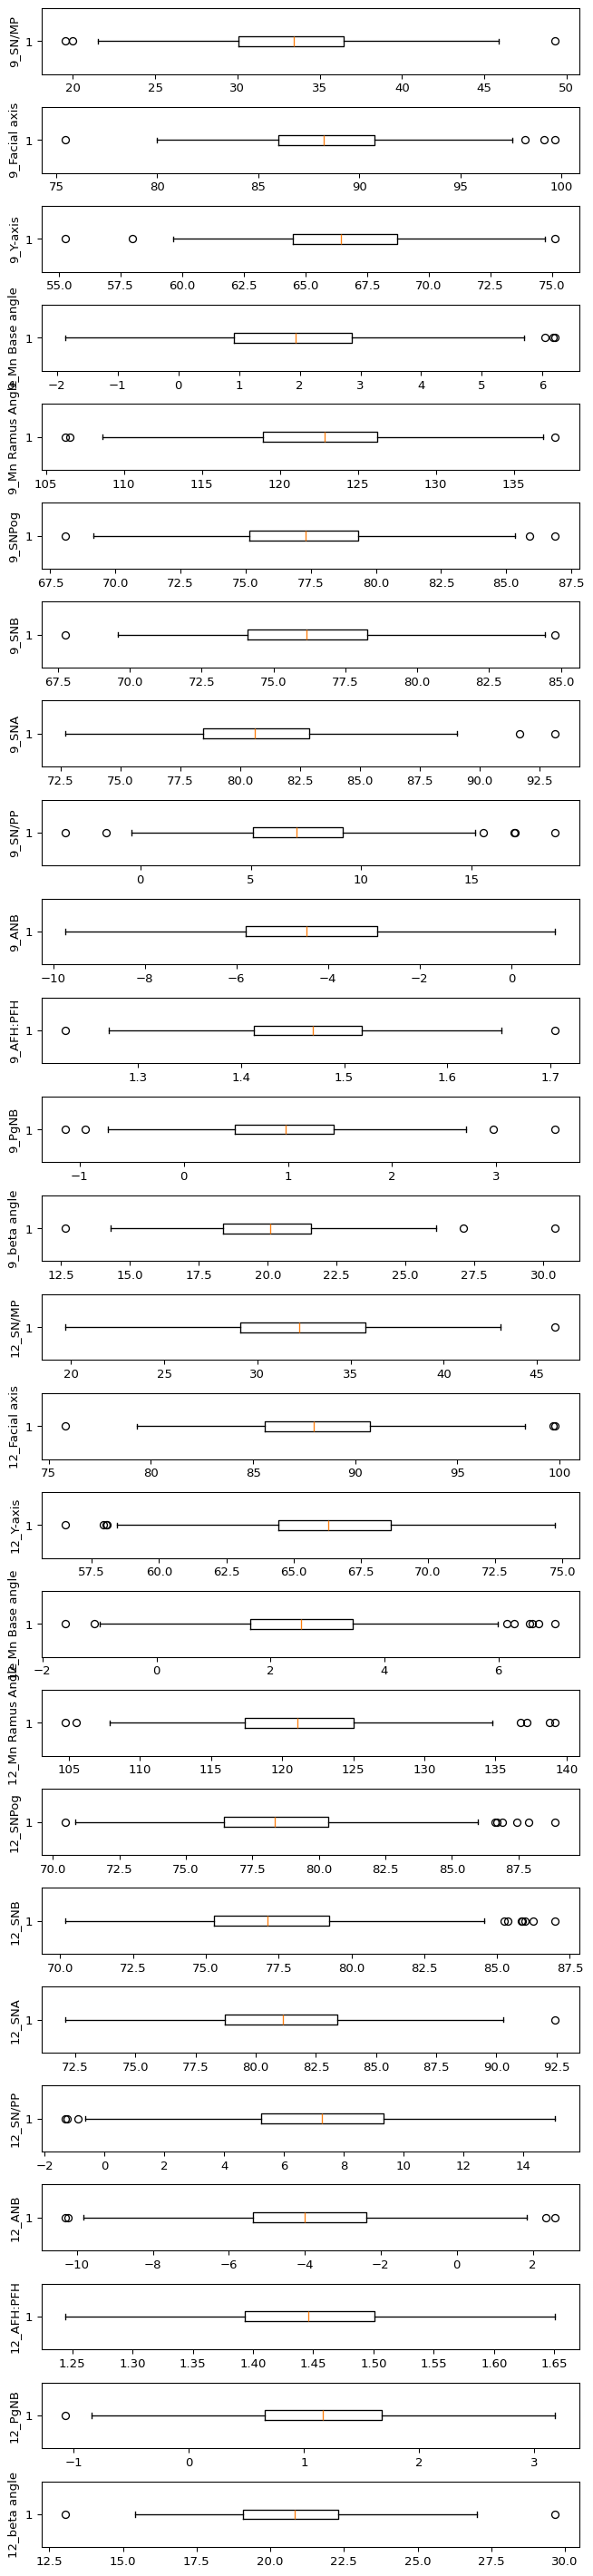

In [10]:
# https://www.geeksforgeeks.org/data-analysis/data-preprocessing-machine-learning-python/
fig, axs = plt.subplots(len(x_train.columns), 1, figsize=(7, 30), dpi=95)
for i, col in enumerate(x_train.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
fig.tight_layout()
plt.show()

In [11]:
description = x_train.describe()
description

for column in x_train.columns:
    info_column = description[column]
    q1 = info_column["25%"]
    q3 = info_column["75%"]
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    for idx, value in enumerate(x_train[column]):
        if (value < lower_bound):
            x_train.at[idx, column] = lower_bound
        elif (value > upper_bound):
            x_train.at[idx, column] = upper_bound

x_train.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,...,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,33.329908,88.429247,66.711993,1.984862,122.403535,77.203012,76.206748,80.490612,7.239779,-4.295985,...,2.638274,121.152566,78.308746,77.091185,80.926277,7.175394,-3.819125,1.448256,1.224438,20.809888
std,4.576805,3.558934,3.117427,1.397854,5.376107,3.138135,3.082684,3.344685,3.102756,2.053185,...,1.356900,5.392076,3.065637,3.055707,3.442783,3.043481,2.138528,0.074659,0.727708,2.340768
min,20.379963,79.986000,59.619544,-1.605871,107.935540,68.582419,67.770015,72.707404,-0.601332,-9.422221,...,-0.921815,105.637719,70.537297,70.187880,72.099648,-0.964470,-9.717170,1.257854,-0.917674,15.423892
25%,30.120304,85.884130,64.498021,0.992830,118.727684,75.048479,73.933265,78.337018,5.271956,-5.677250,...,1.741467,117.403034,76.322254,75.091710,78.409743,5.192679,-5.296609,1.392802,0.687853,19.064332
50%,33.356324,88.207560,66.450460,1.999165,122.647783,77.269152,76.087794,80.500595,7.149617,-4.447279,...,2.603896,120.867984,78.161932,77.031837,80.802387,7.275632,-3.952802,1.446865,1.196262,20.820688
75%,36.613865,90.749465,68.590662,2.881121,125.922446,79.359185,78.250140,82.749477,9.187482,-2.809693,...,3.516989,125.246577,80.178892,79.070653,83.286280,9.297446,-2.349569,1.501416,1.758203,22.314127
max,46.354206,98.047467,74.729623,5.713557,136.714590,85.825245,84.458895,89.368166,15.060771,0.945465,...,6.180271,137.011892,85.963848,85.039066,90.285665,15.053215,2.070991,1.650425,3.176099,27.188821


In [12]:
print(x_train.corr())

                    9_SN/MP  9_Facial axis  9_Y-axis  9_Mn Base angle  \
9_SN/MP            1.000000       0.645847  0.772811        -0.069916   
9_Facial axis      0.645847       1.000000  0.818126        -0.137867   
9_Y-axis           0.772811       0.818126  1.000000        -0.092985   
9_Mn Base angle   -0.069916      -0.137867 -0.092985         1.000000   
9_Mn Ramus Angle   0.605904       0.159379  0.177252        -0.037959   
9_SNPog           -0.694636      -0.559575 -0.815129         0.077833   
9_SNB             -0.625105      -0.474985 -0.754227         0.026534   
9_SNA             -0.471965      -0.245712 -0.517923        -0.032003   
9_SN/PP            0.391395       0.316009  0.462581        -0.016177   
9_ANB             -0.165572      -0.315704 -0.286316         0.102505   
9_AFH:PFH          0.927444       0.487434  0.676614        -0.049914   
9_PgNB            -0.367571      -0.419282 -0.342925         0.242458   
9_beta angle      -0.706755      -0.218448 -0.23197

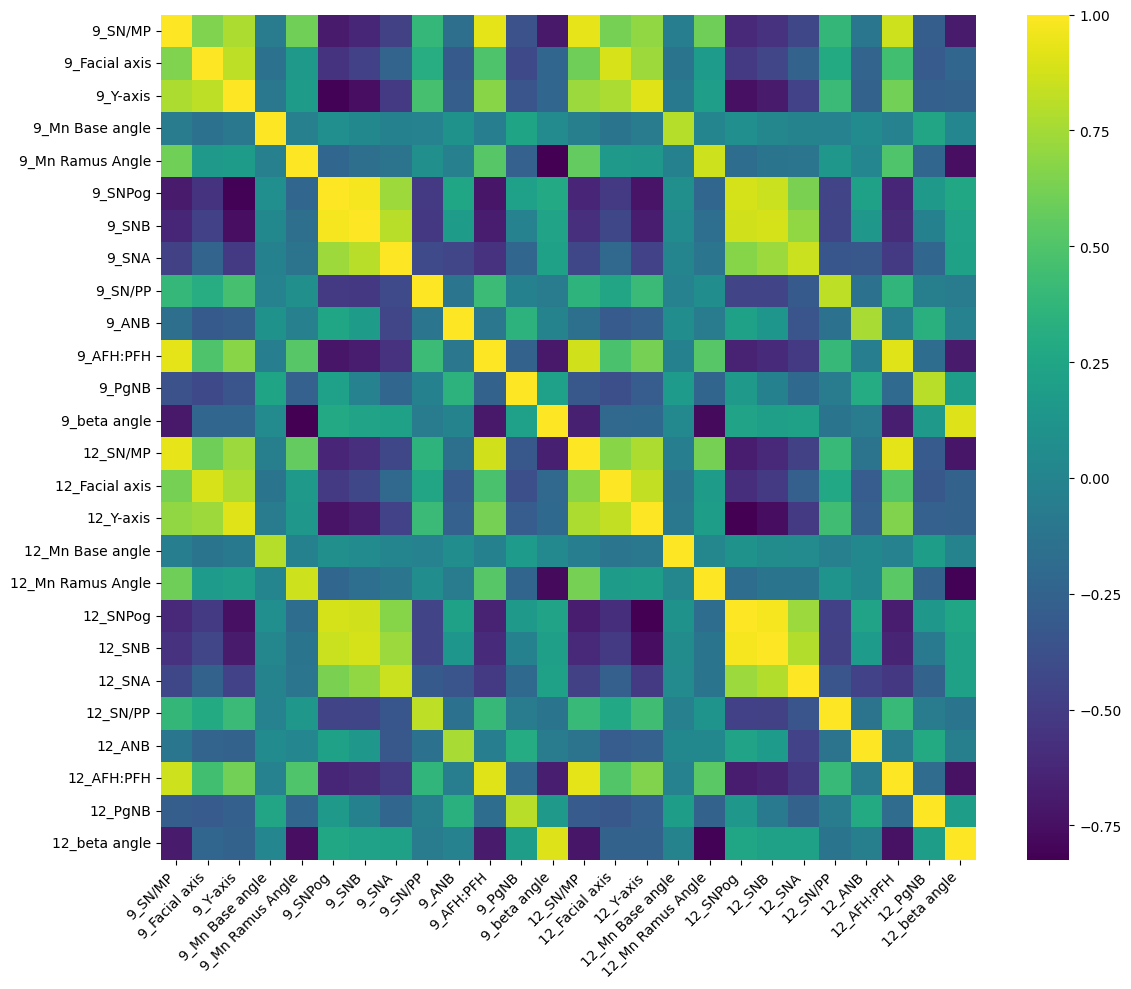

In [13]:
#ai generated
corr = x_train.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, ax=ax, cbar=True, cmap='viridis')

ax.set_xticks([i + 0.5 for i in range(len(corr.columns))])
ax.set_yticks([i + 0.5 for i in range(len(corr.index))])

ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
x_train.drop('9_SNPog', axis=1, inplace=True)
x_train.drop('12_SNPog', axis=1, inplace=True)

x_test.drop('9_SNPog', axis=1, inplace=True)
x_test.drop('12_SNPog', axis=1, inplace=True)

In [15]:
values_occurences = y_train.value_counts()
print(values_occurences)

growth direction
1    172
0    131
2      9
Name: count, dtype: int64


In [16]:
smote = SMOTE(sampling_strategy='not majority', random_state=123)
x_train, y_train = smote.fit_resample(x_train, y_train)


In [17]:
scaler = StandardScaler()

scaler.fit(x_train)
x_train = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

x_train.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNB,9_SNA,9_SN/PP,9_ANB,9_AFH:PFH,...,12_Y-axis,12_Mn Base angle,12_Mn Ramus Angle,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle
count,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,...,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02,5.160000e+02
mean,-4.131062e-16,8.124423e-16,-2.671420e-15,-3.167148e-16,1.927829e-16,1.432102e-15,-3.084527e-15,2.340935e-16,-6.885104e-17,1.101617e-15,...,-1.927829e-16,2.581914e-17,-6.885104e-16,2.230774e-15,2.588799e-15,-2.203233e-16,1.790127e-16,4.681871e-16,-1.101617e-16,5.783487e-16
std,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,...,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00,1.000970e+00
min,-3.032195e+00,-2.733923e+00,-2.697037e+00,-3.140268e+00,-2.942919e+00,-2.922148e+00,-2.351463e+00,-2.804729e+00,-2.788458e+00,-2.772191e+00,...,-3.043489e+00,-2.643711e+00,-2.982917e+00,-2.320757e+00,-2.556176e+00,-3.070340e+00,-3.040196e+00,-2.739520e+00,-2.890502e+00,-1.619052e+00
25%,-7.801670e-01,-7.925321e-01,-6.757629e-01,-4.758747e-01,-6.053694e-01,-6.145231e-01,-6.690922e-01,-5.788956e-01,-6.869649e-01,-7.522522e-01,...,-7.365511e-01,-5.973557e-01,-8.271566e-01,-5.595038e-01,-7.258400e-01,-6.740119e-01,-6.510675e-01,-7.733081e-01,-6.331176e-01,-8.824165e-01
50%,2.120916e-01,9.358066e-02,1.228612e-01,1.847392e-02,2.151696e-01,-5.568897e-02,8.420463e-03,-9.351966e-02,-1.288775e-01,1.292649e-01,...,7.681404e-03,4.345411e-02,9.385664e-02,-1.339084e-01,-1.761891e-01,9.998439e-02,-4.973924e-02,1.593969e-01,1.218053e-02,-1.711273e-01
75%,8.151072e-01,7.348266e-01,5.984190e-01,5.460169e-01,6.445409e-01,4.962849e-01,6.171857e-01,6.518101e-01,7.436232e-01,8.395523e-01,...,6.868093e-01,6.381040e-01,8.231867e-01,5.946975e-01,7.168745e-01,6.698807e-01,7.727921e-01,8.115339e-01,6.714560e-01,7.800336e-01
max,2.325032e+00,2.644809e+00,2.568098e+00,3.171394e+00,2.232895e+00,3.131103e+00,3.030534e+00,2.341833e+00,2.713362e+00,2.261901e+00,...,2.391010e+00,2.528286e+00,2.174474e+00,3.056826e+00,3.175069e+00,2.489719e+00,2.825688e+00,2.137397e+00,2.970502e+00,2.833626e+00


In [18]:
def calculate_metrcs(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    return (accuracy, precision, f1, recall)

def print_metrics(metrics):
    print(f'Accuracy: {metrics[0] * 100:.2f}%')
    print(f'Precision: {metrics[1]:.3f}')
    print(f'F1 score: {metrics[2]:.3f}')
    print(f'Recall: {metrics[3]:.3f}')

In [19]:
estim = RandomForestClassifier(random_state=rng)
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

# params_grid = {
#     'n_estimators': [60, 120, 250, 300, 350, 500],
#     'max_depth': [4, 6, 8, 12, 16, None],
#     'max_features': [4, 8, 12, 16, 26],
#     'min_samples_leaf': [1, 2, 4, 6, 8]
# }

params_grid = {
    'n_estimators': [60, 120, 300],
    'max_depth': [6, 8, None],
    'max_features': [4, 12, 16, 26],
    'min_samples_leaf': [1, 2, 4]
}

forest = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)

forest.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...om_state=1234)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 8, ...], 'max_features': [4, 12, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [60, 120, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [20]:
y_pred = forest.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 80.60%
Precision: 0.713
F1 score: 0.702
Recall: 0.693


In [21]:
# esimators = [40, 60, 100, 120, 130, 140, 200, 300, 500, 700, 1000]

# for est in esimators:
#     print("Random forest with " + str(est) + " trees")
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=est, random_state=rng)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [22]:
# depths = [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 80, 100, None]

# for depth in depths:
#     print("Random forest with max depth: " + str(depth))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, max_depth=depth)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [23]:
# max_features = [2, 4, 6, 8, 12, 16, 20, 24, 26]

# for maxf in max_features:
#     print("Random forest with max features: " + str(maxf))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, max_features=maxf)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [24]:
# min_leafs = [1, 2, 4, 8, 16]

# for minl in min_leafs:
#     print("Random forest with min_samples_leaf: " + str(minl))
#     avg = 0.0
#     loops = 30
#     for i in range(0, loops):    
#         forest = RandomForestClassifier(n_estimators=100, random_state=rng, min_samples_leaf=minl)
#         forest.fit(x_train, y_train)
#         y_pred = forest.predict(x_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         avg += accuracy
#     avg = avg / loops
#     print(f'Avg accuracy: {avg * 100:.2f}%')

In [25]:
estim = KNeighborsClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

params_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40]
}

neighbors = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)
neighbors.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [26]:
y_pred = neighbors.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 67.91%
Precision: 0.601
F1 score: 0.601
Recall: 0.602


In [34]:
estim = LogisticRegression(random_state=rng)
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

params_grid = {
    'C': [0.3, 0.4, 0.5, 1.0, 3.0]
}

logreg = GridSearchCV(estimator=estim, param_grid=params_grid, scoring='accuracy', n_jobs=-1)
logreg.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...om_state=1234)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.3, 0.4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate par

In [28]:
y_pred = logreg.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 74.63%
Precision: 0.695
F1 score: 0.728
Recall: 0.813
